#Import upload

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/drive/MyDrive/EDA PROJ/ProjectData/gas_monitoring.db')

In [3]:
import sqlite3
import pandas as pd

# 2. Load the entire table into a Pandas DataFrame
df = pd.read_sql_query("SELECT * FROM gas_monitoring", conn)

# 3. Close the connection (best practice!)
conn.close()

#First data analysis

In [4]:
print(df.describe())

        Temperature     Humidity  CO2_InfraredSensor  \
count  10000.000000  8072.000000        10000.000000   
mean      42.243124    51.643609          109.864352   
std       73.974956    21.333894           33.793851   
min        6.903485   -49.870000          -17.472184   
25%       18.937500    47.660000           96.660377   
50%       20.510000    51.390000          112.807103   
75%       23.172500    53.840000          124.540226   
max      307.070000   198.900000          237.873938   

       CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  \
count               10000.000000            10000.000000   
mean                  578.634082              470.932316   
std                    22.573537               51.459025   
min                   408.599386              286.825662   
25%                   559.353100              440.035413   
50%                   579.361082              469.146955   
75%                   595.569759              494.770045   
max            

#Time of Day

In [5]:
time_mapping = {
    'morning': 1,
    'afternoon': 2,
    'evening': 3,
    'night': 4
}

df['Time of Day'] = df['Time of Day'].map(time_mapping)

#Temperature

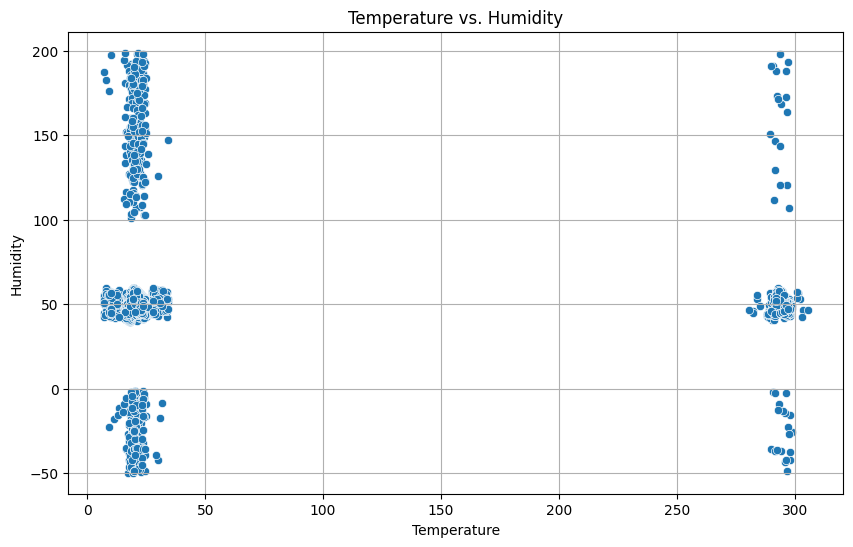

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature', y='Humidity')
plt.title('Temperature vs. Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.grid(True)
plt.show()

In [7]:
import numpy as np

# Assuming values > 250 are in Kelvin and need conversion to Celsius
# C = K - 273.15

df.loc[df['Temperature'] > 250, 'Temperature'] = df.loc[df['Temperature'] > 250, 'Temperature'] - 273.15

print("Temperature values greater than 250 Kelvin have been converted to Celsius.")
print("Here are the first few rows of the updated 'Temperature' column where conversions occurred (if any):")
display(df[df['Temperature'] < 50]['Temperature'].head())


Temperature values greater than 250 Kelvin have been converted to Celsius.
Here are the first few rows of the updated 'Temperature' column where conversions occurred (if any):


,Temperature
0,19.63
1,19.66
2,19.62
3,20.10
4,19.89


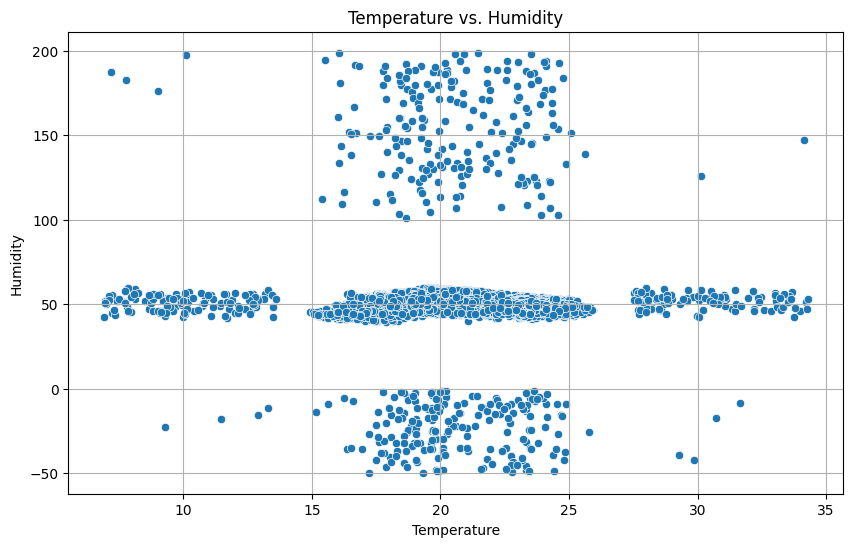

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature', y='Humidity')
plt.title('Temperature vs. Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.grid(True)
plt.show()

#Humidity

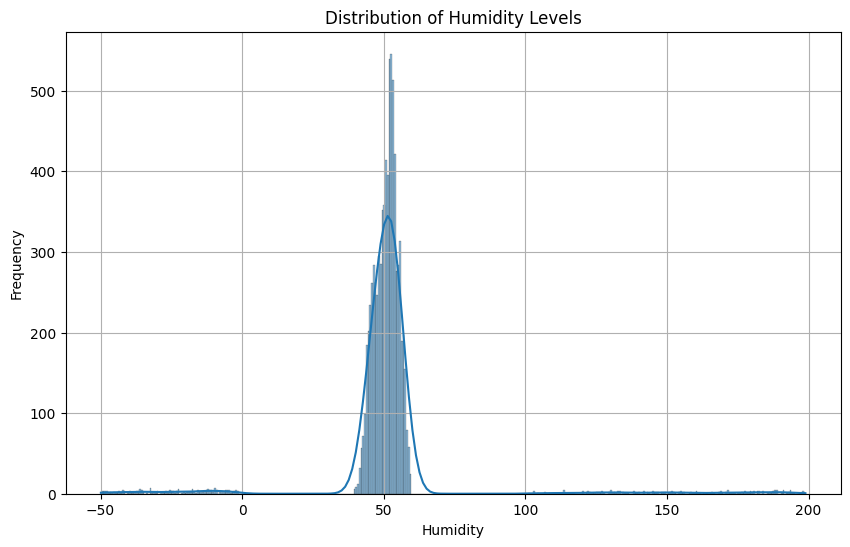

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Humidity'].dropna(), kde=True)
plt.title('Distribution of Humidity Levels')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [10]:
import numpy as np

# Replace humidity values outside the 0-100 range with NaN
df.loc[(df['Humidity'] < 0) | (df['Humidity'] > 100), 'Humidity'] = np.nan

print("Humidity values outside the 0-100 range have been replaced with NaN.")
print("Here are the first few rows of the 'Humidity' column after the update:")
display(df['Humidity'].head())

Humidity values outside the 0-100 range have been replaced with NaN.
Here are the first few rows of the 'Humidity' column after the update:


,Humidity
0,53.83
1,53.69
2,54.25
3,50.48
4,48.42


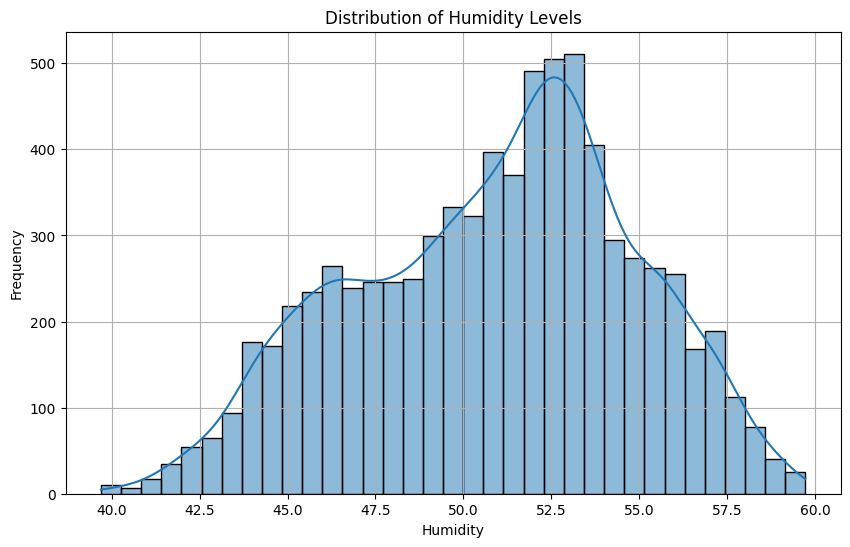

In [11]:


plt.figure(figsize=(10, 6))
sns.histplot(df['Humidity'].dropna(), kde=True)
plt.title('Distribution of Humidity Levels')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#CO2_Sensors



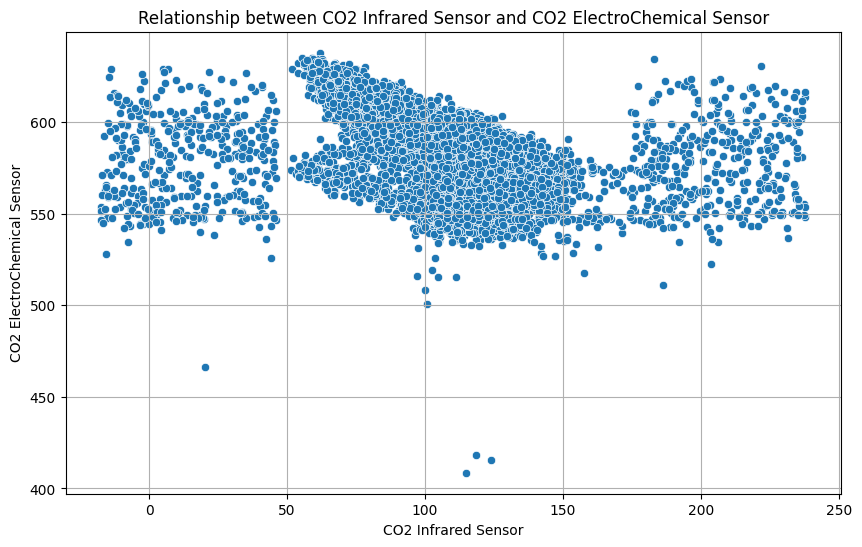

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CO2_InfraredSensor', y='CO2_ElectroChemicalSensor')
plt.title('Relationship between CO2 Infrared Sensor and CO2 ElectroChemical Sensor')
plt.xlabel('CO2 Infrared Sensor')
plt.ylabel('CO2 ElectroChemical Sensor')
plt.grid(True)
plt.show()

assume that c02 infared sensor is wrongly callibrated so the natural 0 is negative, since only 4 rows are below 475 for electrochemical sensor, safe to assume sensor faulty.

In [13]:
df = df[df['CO2_ElectroChemicalSensor'] >= 475]

In [14]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Reshape the column to a 2D array as required by the scaler
# Handle potential NaN values by filling them or dropping them before scaling if necessary
# For this example, we'll scale non-NaN values and keep NaN values as they are.

# Create a mask for non-NaN values
not_nan_mask = df['CO2_InfraredSensor'].notna()

# Apply scaler only to non-NaN values
df.loc[not_nan_mask, 'CO2_InfraredSensor'] = scaler.fit_transform(df.loc[not_nan_mask, 'CO2_InfraredSensor'].values.reshape(-1, 1))

print("Min-Max scaling applied to 'CO2_InfraredSensor' column.")
print("Here are the first few rows of the scaled 'CO2_InfraredSensor' column:")
display(df['CO2_InfraredSensor'].head())

Min-Max scaling applied to 'CO2_InfraredSensor' column.
Here are the first few rows of the scaled 'CO2_InfraredSensor' column:


,CO2_InfraredSensor
0,0.559862
1,0.563217
2,0.564069
3,0.512939
4,0.431721


In [15]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Initialize the StandardScaler
scaler_standard = StandardScaler()

# Create a mask for non-NaN values in 'CO2_ElectroChemicalSensor'
not_nan_mask_electro = df['CO2_ElectroChemicalSensor'].notna()

# Apply scaler only to non-NaN values
df.loc[not_nan_mask_electro, 'CO2_ElectroChemicalSensor'] = scaler_standard.fit_transform(df.loc[not_nan_mask_electro, 'CO2_ElectroChemicalSensor'].values.reshape(-1, 1))

print("Standard scaling applied to 'CO2_ElectroChemicalSensor' column.")
print("Here are the first few rows of the scaled 'CO2_ElectroChemicalSensor' column:")
display(df['CO2_ElectroChemicalSensor'].head())

Standard scaling applied to 'CO2_ElectroChemicalSensor' column.
Here are the first few rows of the scaled 'CO2_ElectroChemicalSensor' column:


,CO2_ElectroChemicalSensor
0,-0.340003
1,-0.129880
2,0.306170
3,0.838484
4,1.562949


#Metal oxide sensors

In [16]:
metal_oxide_columns = [
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]

# Calculate null values for only the metal oxide columns
null_counts_metal_oxide = df[metal_oxide_columns].isnull().sum()

# Filter to show only columns that actually have null values
null_counts_metal_oxide = null_counts_metal_oxide[null_counts_metal_oxide > 0]

if not null_counts_metal_oxide.empty:
    print("Metal Oxide Sensor columns with null values and their counts:")
    display(null_counts_metal_oxide)
else:
    print("No null values found in any of the Metal Oxide Sensor columns.")

Metal Oxide Sensor columns with null values and their counts:


,0
MetalOxideSensor_Unit2,1410


In [17]:
from sklearn.preprocessing import StandardScaler
import numpy as np

metal_oxide_columns = [
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]

scaler_metal_oxide = StandardScaler()

for col in metal_oxide_columns:
    # Create a mask for non-NaN values for the current column
    not_nan_mask_col = df[col].notna()

    # Apply scaler only to non-NaN values
    df.loc[not_nan_mask_col, col] = scaler_metal_oxide.fit_transform(df.loc[not_nan_mask_col, col].values.reshape(-1, 1))
    print(f"Standard scaling applied to '{col}' column.")

print("\nHere are the first few rows of the scaled metal oxide sensor columns:")
display(df[metal_oxide_columns].head())

Standard scaling applied to 'MetalOxideSensor_Unit1' column.
Standard scaling applied to 'MetalOxideSensor_Unit2' column.
Standard scaling applied to 'MetalOxideSensor_Unit3' column.
Standard scaling applied to 'MetalOxideSensor_Unit4' column.

Here are the first few rows of the scaled metal oxide sensor columns:


,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4
0,0.148403,0.258601,-0.461818,-1.092977
1,0.408812,0.410870,-0.441994,-1.277697
2,0.673213,0.301973,-0.545165,-1.254838
3,0.859411,0.539283,-0.077069,-0.278193
4,1.258225,1.440901,0.711634,0.312768


#CO_GasSensor

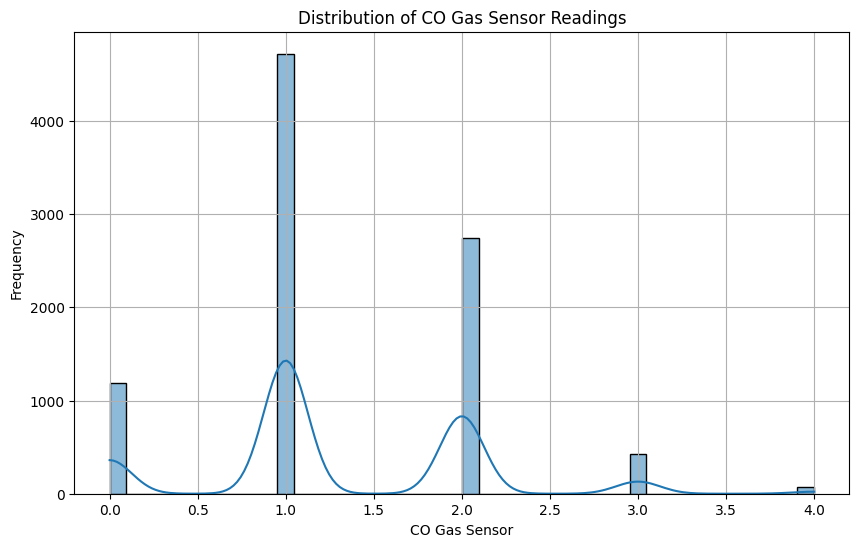

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['CO_GasSensor'].dropna(), kde=True)
plt.title('Distribution of CO Gas Sensor Readings')
plt.xlabel('CO Gas Sensor')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#Hvac Operation Mode

In [19]:
df['HVAC Operation Mode'] = df['HVAC Operation Mode'].str.upper()
df = pd.get_dummies(df, columns=['HVAC Operation Mode'], prefix='HVAC_Mode', drop_first=True, dtype=int)

#Ambient Light Level

In [20]:
light_mapping = {
    'very_dim': 0,
    'dim': 1,
    'moderate': 2,
    'bright': 3,
    'very_bright': 4
}

df['Ambient Light Level'] = df['Ambient Light Level'].map(light_mapping)

#Activity Level

In [21]:
target_mapping = {
    'Low Activity': 0,
    'Low_Activity': 0,
    'LowActivity': 0,
    'Moderate Activity': 1,
    'ModerateActivity': 1,
    'High Activity': 2
}


df['Activity Level'] = df['Activity Level'].map(target_mapping)

#Second Data analysis

In [22]:
print(df.describe())

       Time of Day  Temperature     Humidity  CO2_InfraredSensor  \
count  9996.000000  9996.000000  7654.000000         9996.000000   
mean      2.487995    20.528596    50.876945            0.498706   
std       1.107867     2.850084     3.969190            0.132324   
min       1.000000     6.903485    39.690000            0.000000   
25%       2.000000    18.830000    47.910000            0.446972   
50%       2.000000    20.200000    51.390000            0.510199   
75%       3.000000    22.600000    53.690000            0.556192   
max       4.000000    34.301271    59.730000            1.000000   

       CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  \
count               9.996000e+03            9.996000e+03   
mean                2.479365e-15           -7.790665e-16   
std                 1.000050e+00            1.000050e+00   
min                -3.493983e+00           -3.577509e+00   
25%                -8.643543e-01           -6.003291e-01   
50%                 3.09084

In [23]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Columns with missing values and their counts:")
    print(missing_values)
else:
    print("No missing values found in the DataFrame.")

Columns with missing values and their counts:
Humidity                  2342
MetalOxideSensor_Unit2    1410
CO_GasSensor               834
Ambient Light Level       1052
dtype: int64


In [24]:
initial_rows = df.shape[0]

# Calculate the number of missing values per row
missing_count_per_row = df.isnull().sum(axis=1)

# Filter out rows that have 3 or more missing values
df = df[missing_count_per_row < 3]

rows_removed = initial_rows - df.shape[0]

print(f"Removed {rows_removed} rows that had 3 or more missing values.")
print(f"DataFrame now has {df.shape[0]} rows.")

Removed 86 rows that had 3 or more missing values.
DataFrame now has 9910 rows.


#NAN value imputation

In [25]:
import numpy as np
import pandas as pd

def impute_numerical_column(df_input, column_name):
    """
    Imputes missing values in a specified numerical column of a DataFrame
    using a bounded stochastic (Gaussian) method based on 'Session ID' and 'Time of Day'.

    Args:
        df_input (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the numerical column to impute.

    Returns:
        pd.DataFrame: The DataFrame with imputed values, or rows dropped if imputation wasn't possible.
    """
    df = df_input.copy() # Work on a copy to avoid modifying the original directly
    rows_to_drop = []

    # Iterate through rows with missing values in the target column
    for index, row in df[df[column_name].isnull()].iterrows():
        session_id = row['Session ID']
        time_of_day = row['Time of Day']

        # Filter for relevant non-null data for context
        df_context = df[
            (df['Session ID'] == session_id) &
            (df['Time of Day'] == time_of_day) &
            (df[column_name].notna())
        ]

        # Fallback Strategy: Check if context is sufficient
        if df_context.empty or df_context[column_name].nunique() < 2: # Need at least 2 unique values to get a meaningful std
            rows_to_drop.append(index)
            continue # Move to the next missing value

        mean_val = df_context[column_name].mean()
        std_val = df_context[column_name].std()
        min_val = df_context[column_name].min()
        max_val = df_context[column_name].max()

        # If std_val is 0 (all values are identical in context), use mean_val directly
        if pd.isna(std_val) or std_val == 0:
            imputed_value = mean_val
        else:
            # Bounded Stochastic Imputation (Gaussian)
            # Generate a random number from a normal distribution
            generated_value = np.random.normal(loc=mean_val, scale=std_val)
            # Clip the generated number to be within the observed min and max
            imputed_value = np.clip(generated_value, min_val, max_val)

        # Assign the imputed value back to the DataFrame copy
        df.loc[index, column_name] = imputed_value

    # Drop rows that couldn't be imputed
    if rows_to_drop:
        print(f"Dropped {len(rows_to_drop)} rows due to insufficient context for imputation.")
        df = df.drop(rows_to_drop)

    return df

print("Imputation function 'impute_numerical_column' defined.")

Imputation function 'impute_numerical_column' defined.


Now, let's apply this function to the columns that still have missing values: `Humidity` and `MetalOxideSensor_Unit2`. We will apply it sequentially.

First, let's check the current missing values:

In [26]:
missing_before_imputation = df.isnull().sum()
missing_before_imputation = missing_before_imputation[missing_before_imputation > 0]

if not missing_before_imputation.empty:
    print("Missing values before imputation:")
    display(missing_before_imputation)
else:
    print("No missing values found in the DataFrame before imputation.")

Missing values before imputation:


,0
Humidity,2266
MetalOxideSensor_Unit2,1340
CO_GasSensor,781
Ambient Light Level,988


Applying imputation for `Humidity`:

In [27]:
df_imputed = impute_numerical_column(df, 'Humidity')
print("Imputation for 'Humidity' complete.")

Dropped 1 rows due to insufficient context for imputation.
Imputation for 'Humidity' complete.


Applying imputation for `MetalOxideSensor_Unit2`:

In [28]:
df_imputed = impute_numerical_column(df_imputed, 'MetalOxideSensor_Unit2')
print("Imputation for 'MetalOxideSensor_Unit2' complete.")

Dropped 3 rows due to insufficient context for imputation.
Imputation for 'MetalOxideSensor_Unit2' complete.


Let's verify the missing values after applying the imputation to both columns:

Applying imputation for `CO_GasSensor`:

In [29]:
df_imputed = impute_numerical_column(df_imputed, 'CO_GasSensor')
print("Imputation for 'CO_GasSensor' complete.")

Dropped 111 rows due to insufficient context for imputation.
Imputation for 'CO_GasSensor' complete.


Applying imputation for `Ambient Light Level`:

In [30]:
df_imputed = impute_numerical_column(df_imputed, 'Ambient Light Level')
print("Imputation for 'Ambient Light Level' complete.")

Imputation for 'Ambient Light Level' complete.


Finally, let's verify if there are any remaining missing values in the DataFrame after all imputations:

In [31]:
missing_after_all_imputations = df_imputed.isnull().sum()
missing_after_all_imputations = missing_after_all_imputations[missing_after_all_imputations > 0]

if not missing_after_all_imputations.empty:
    print("Remaining missing values in DataFrame after all imputations:")
    display(missing_after_all_imputations)
else:
    print("No missing values found in the DataFrame after all imputations.")

# Update the original df with the fully imputed version for subsequent steps
df = df_imputed.copy()

No missing values found in the DataFrame after all imputations.


#Final Data analysis with graph

In [32]:
print(df.describe())

       Time of Day  Temperature     Humidity  CO2_InfraredSensor  \
count  9795.000000  9795.000000  9795.000000         9795.000000   
mean      2.480653    20.528870    50.881907            0.498697   
std       1.107232     2.858239     3.921944            0.132377   
min       1.000000     6.903485    39.690000            0.000000   
25%       2.000000    18.840000    47.961217            0.446471   
50%       2.000000    20.190000    51.345315            0.510271   
75%       3.000000    22.600000    53.690000            0.556136   
max       4.000000    34.301271    59.730000            1.000000   

       CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  \
count                9795.000000             9795.000000   
mean                    0.000320               -0.002207   
std                     1.000602                1.001462   
min                    -3.493983               -3.577509   
25%                    -0.864694               -0.606951   
50%                     0.0

Generating Histograms for Numerical Columns...


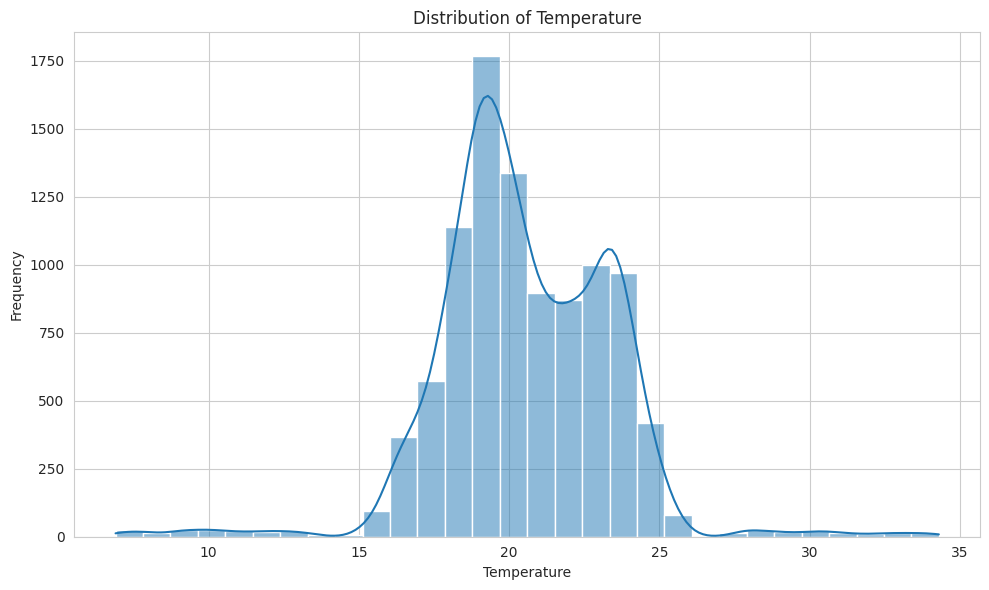

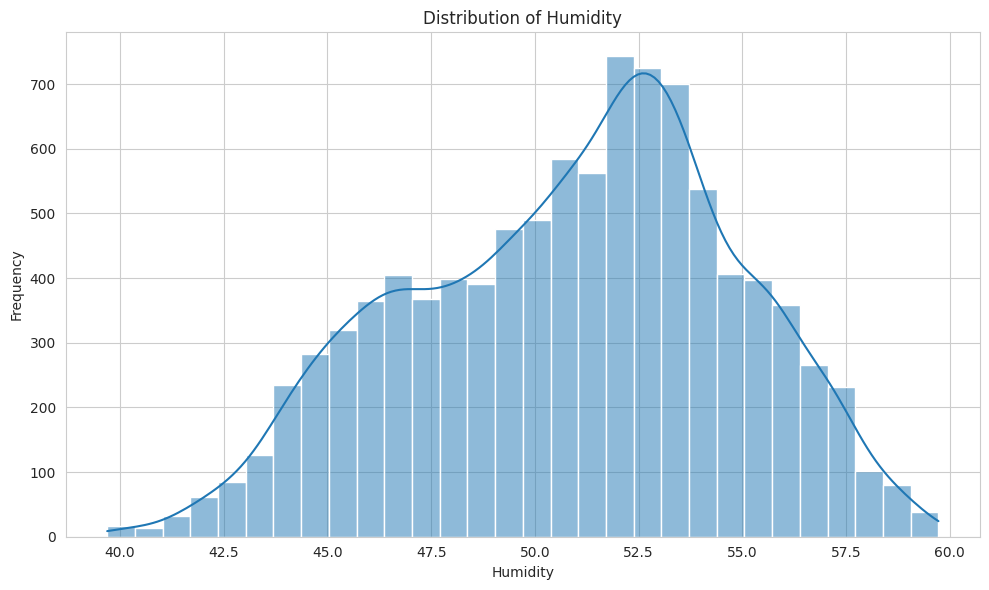

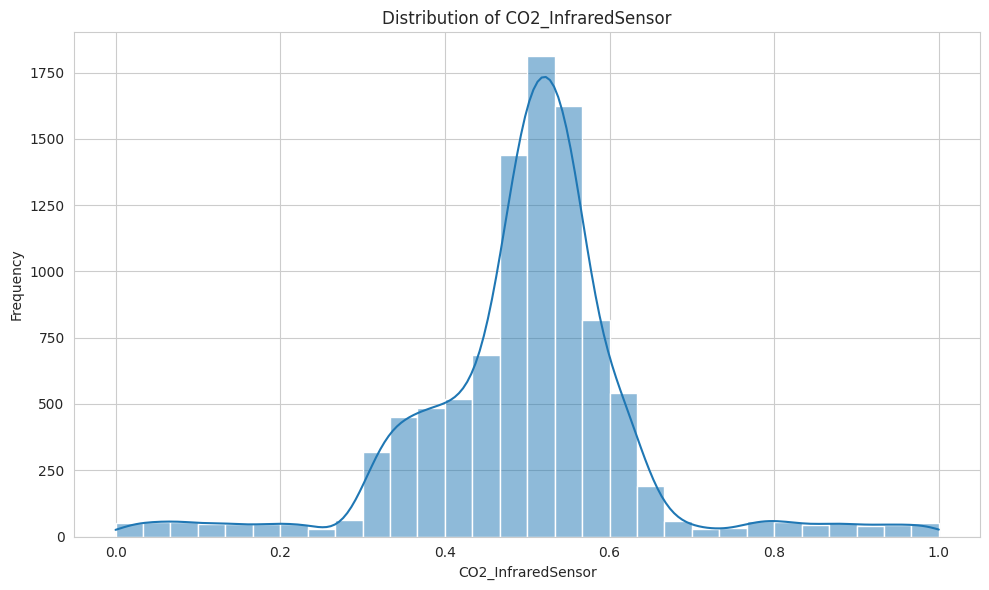

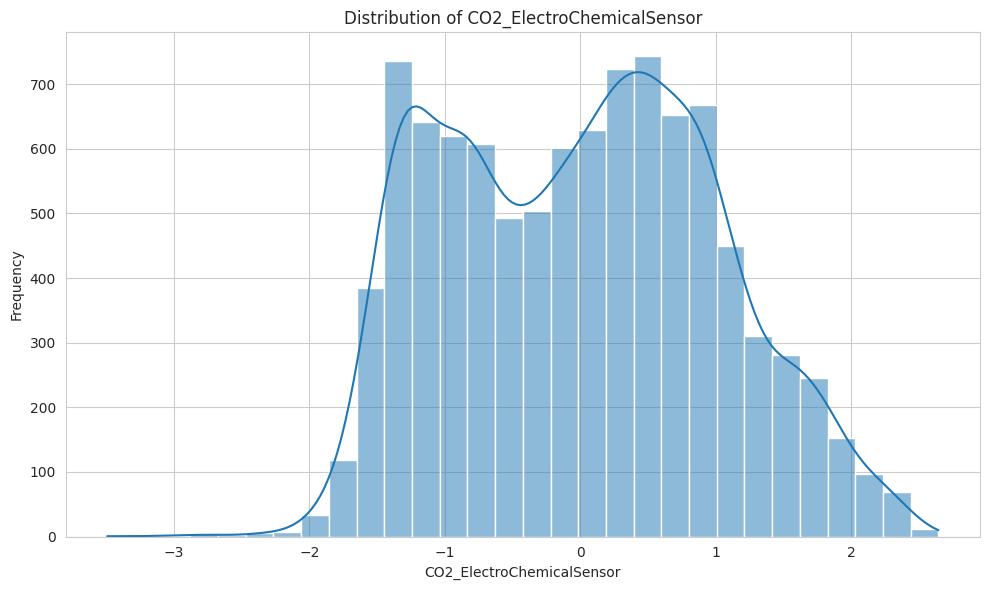

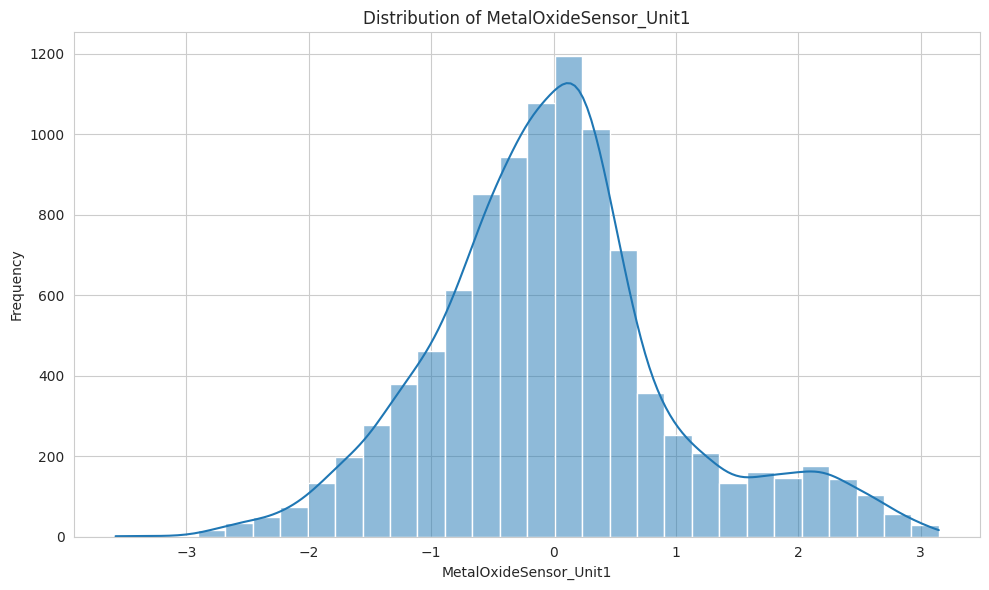

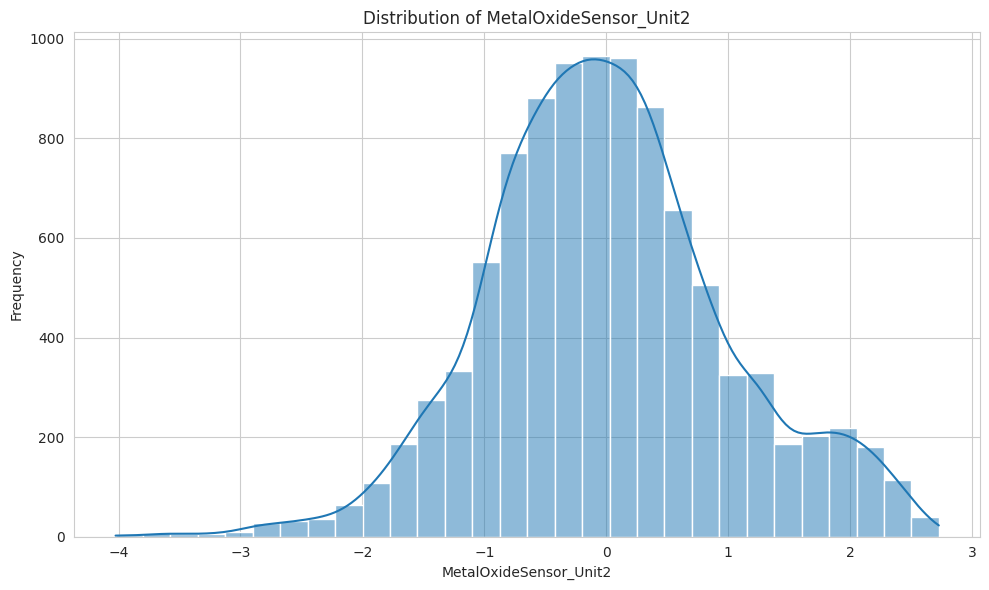

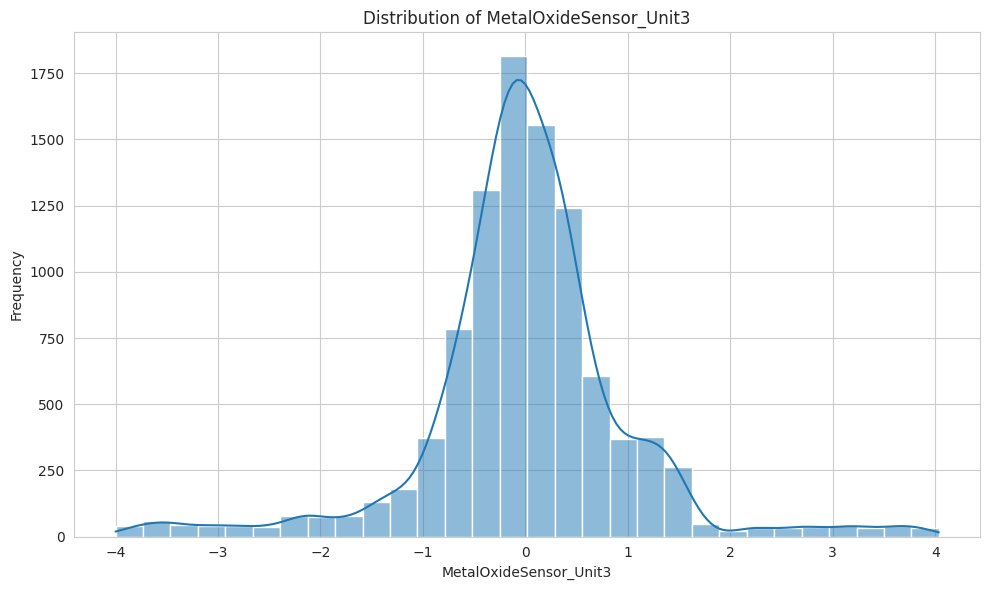

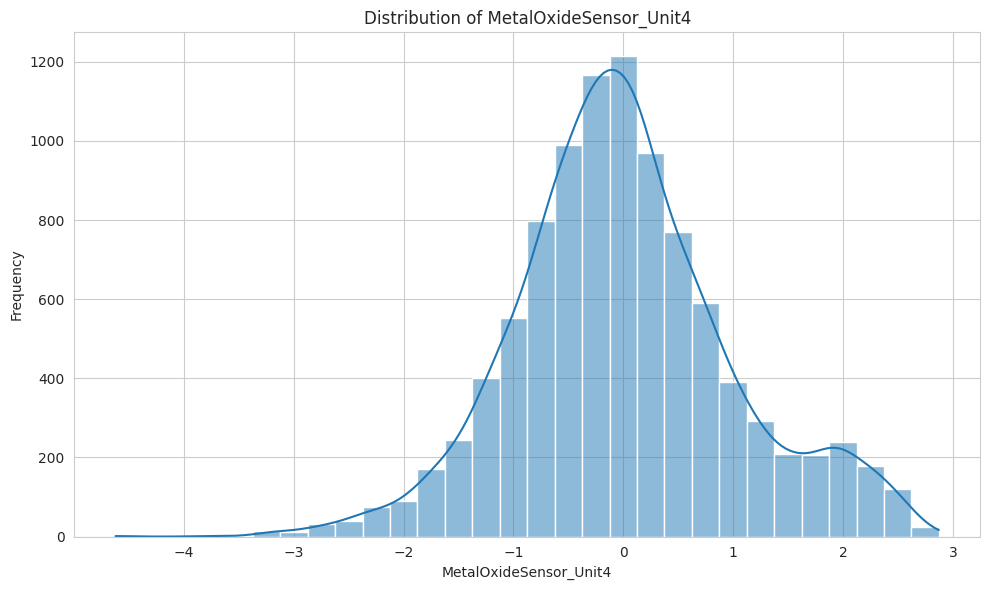

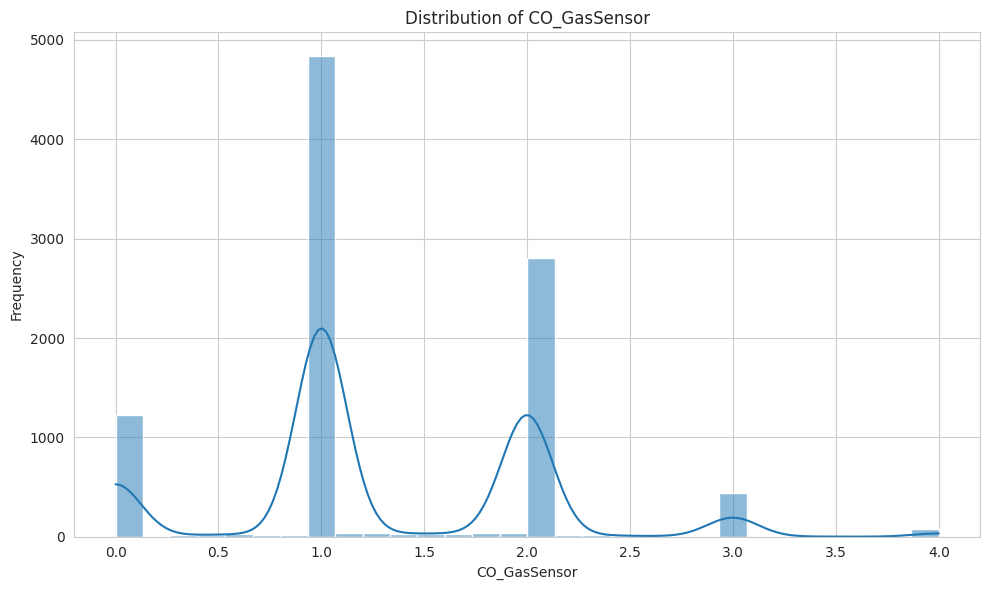


Generating Bar Charts for Categorical/Ordinal Columns...


/tmp/ipykernel_57537/2090592579.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


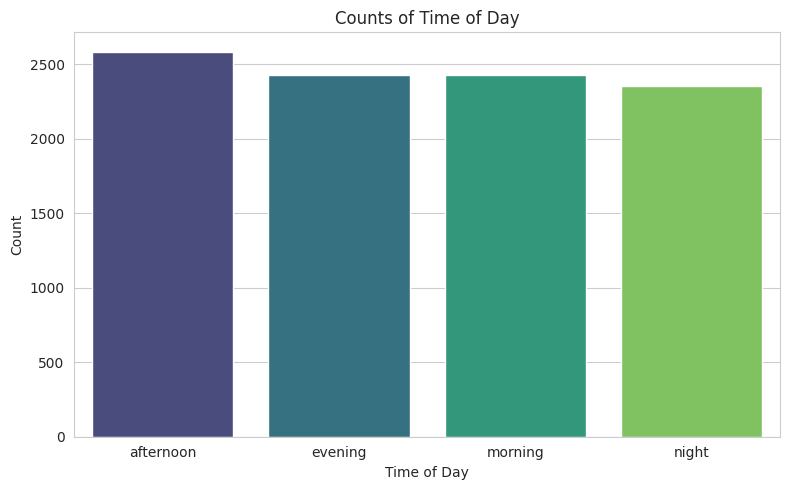

/tmp/ipykernel_57537/2090592579.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


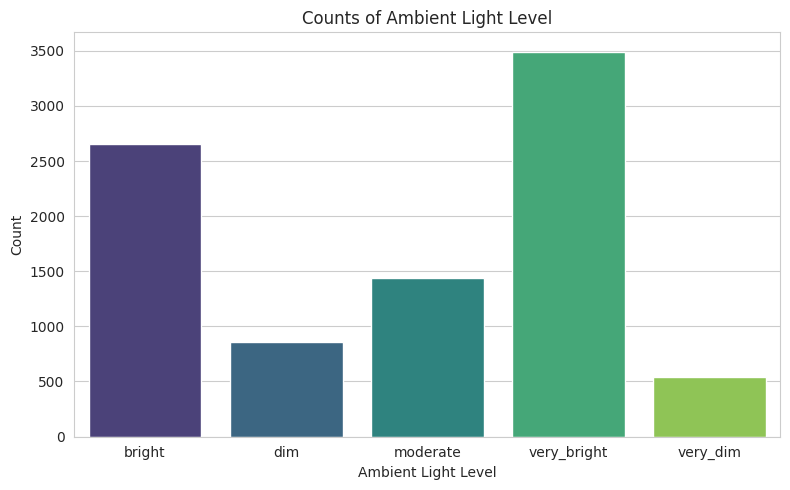

/tmp/ipykernel_57537/2090592579.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


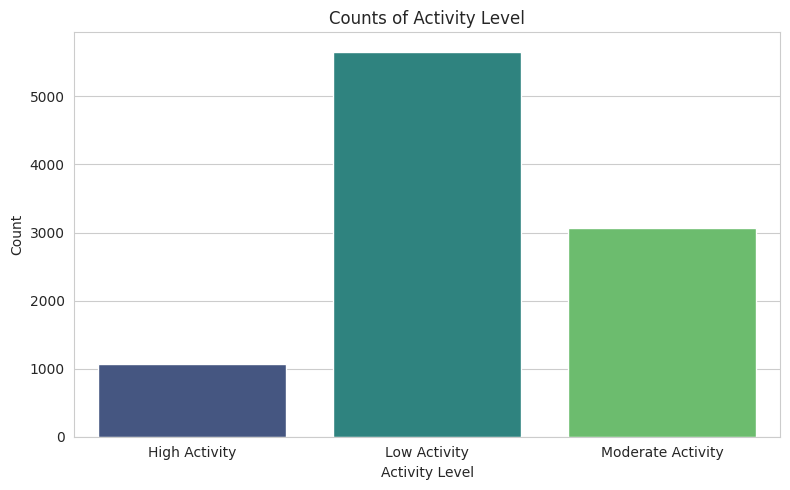

/tmp/ipykernel_57537/2090592579.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mode', y='Count', data=counts_df, palette='cividis')



Generating Bar Charts for HVAC Operation Modes...


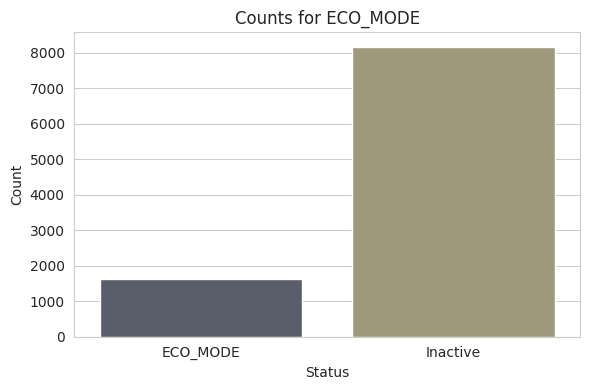

/tmp/ipykernel_57537/2090592579.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mode', y='Count', data=counts_df, palette='cividis')


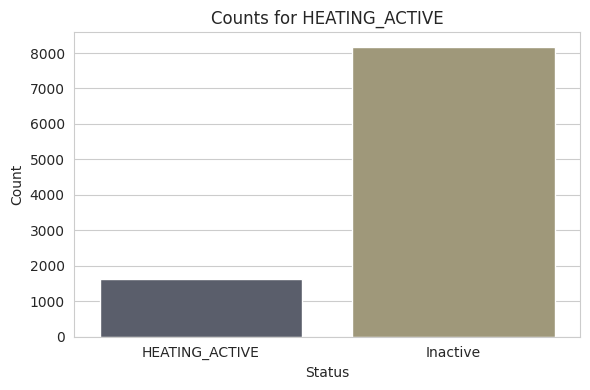

/tmp/ipykernel_57537/2090592579.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mode', y='Count', data=counts_df, palette='cividis')


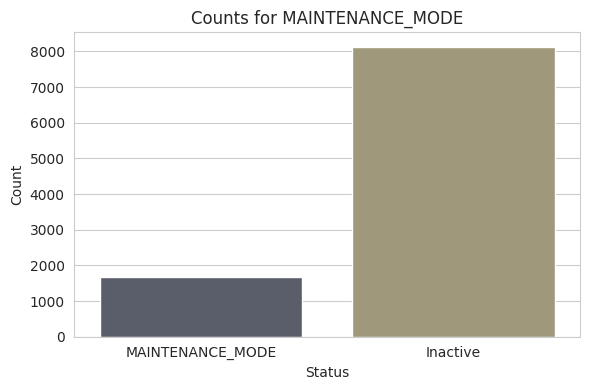

/tmp/ipykernel_57537/2090592579.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mode', y='Count', data=counts_df, palette='cividis')


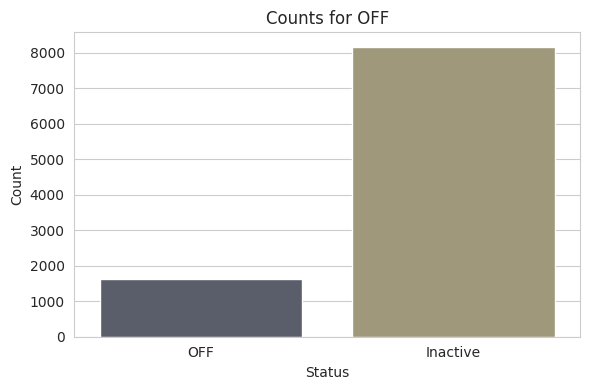

/tmp/ipykernel_57537/2090592579.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mode', y='Count', data=counts_df, palette='cividis')


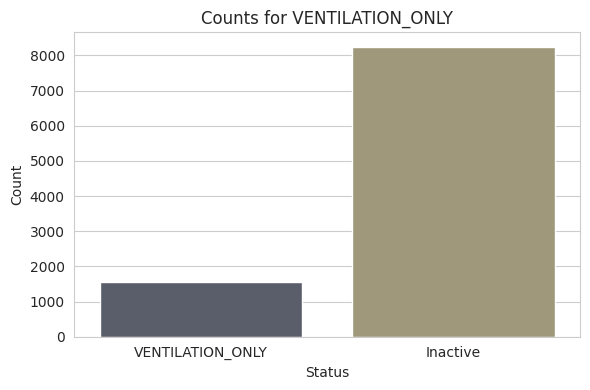


Generating Selected Scatter Plots for Relationships...


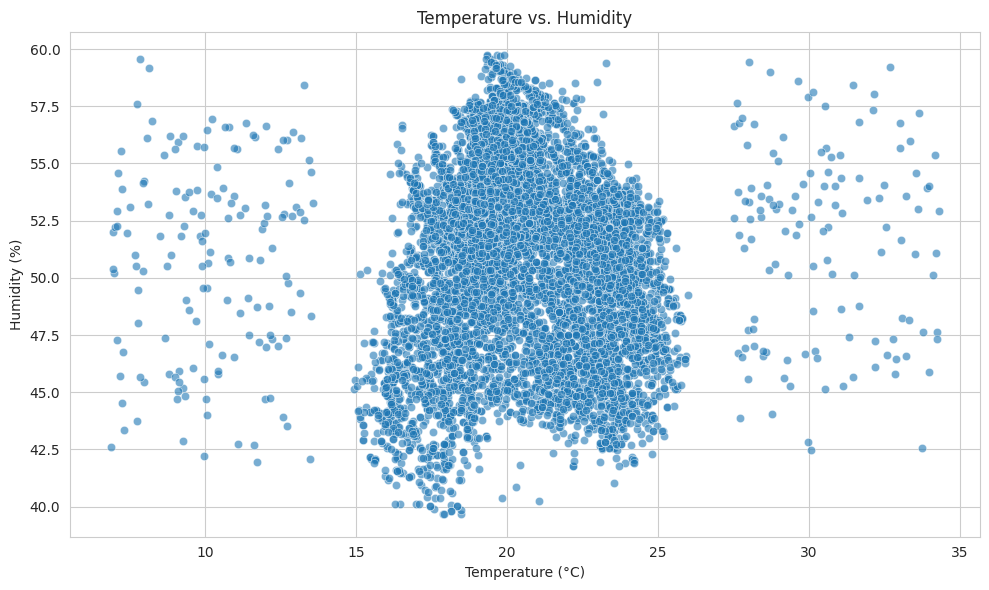

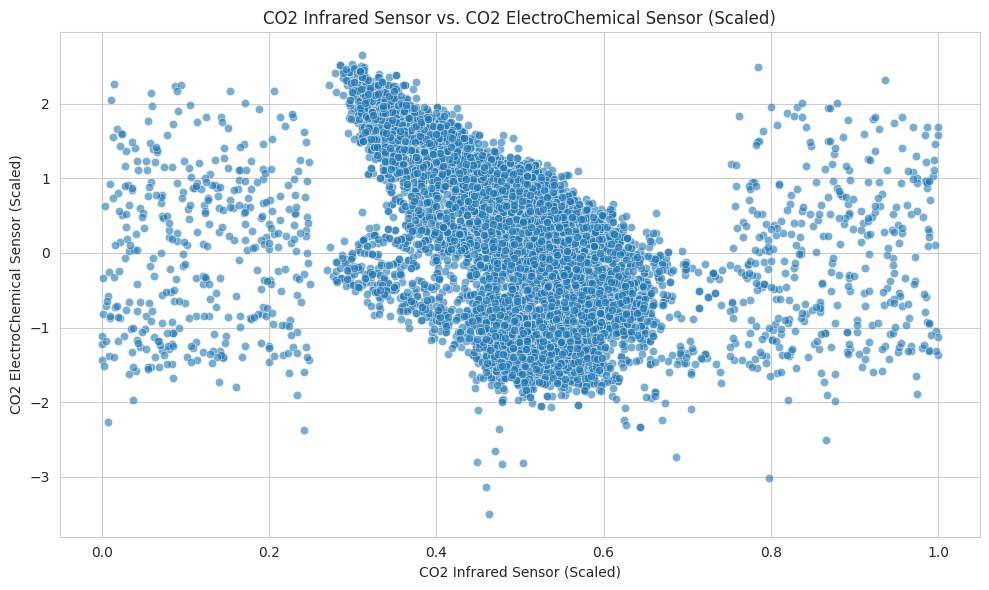

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# --- 1. Histograms for Numerical Sensor Readings and Environmental Factors ---

numerical_cols = [
    'Temperature',
    'Humidity',
    'CO2_InfraredSensor',
    'CO2_ElectroChemicalSensor',
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4',
    'CO_GasSensor'
]

print("Generating Histograms for Numerical Columns...")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# --- 2. Bar Charts for Categorical/Ordinal Features ---

categorical_cols = [
    'Time of Day',
    'Ambient Light Level',
    'Activity Level'
]

# Mapping dictionaries for better labels
time_of_day_labels = {1: 'morning', 2: 'afternoon', 3: 'evening', 4: 'night'}
ambient_light_labels = {0: 'very_dim', 1: 'dim', 2: 'moderate', 3: 'bright', 4: 'very_bright'}
activity_level_labels = {0: 'Low Activity', 1: 'Moderate Activity', 2: 'High Activity'}

mappings = {
    'Time of Day': time_of_day_labels,
    'Ambient Light Level': ambient_light_labels,
    'Activity Level': activity_level_labels
}

print("\nGenerating Bar Charts for Categorical/Ordinal Columns...")
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    counts = df[col].map(mappings[col]).value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, palette='viridis')
    plt.title(f'Counts of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# --- 3. Bar Charts for HVAC Operation Modes (one-hot encoded) ---

hvac_mode_cols = [
    'HVAC_Mode_ECO_MODE',
    'HVAC_Mode_HEATING_ACTIVE',
    'HVAC_Mode_MAINTENANCE_MODE',
    'HVAC_Mode_OFF',
    'HVAC_Mode_VENTILATION_ONLY'
]

print("\nGenerating Bar Charts for HVAC Operation Modes...")
for col in hvac_mode_cols:
    plt.figure(figsize=(6, 4))
    # Count occurrences where the mode is active (value is 1)
    active_count = df[col].sum()
    inactive_count = df.shape[0] - active_count
    counts_df = pd.DataFrame({
        'Mode': [col.replace('HVAC_Mode_', ''), 'Inactive'],
        'Count': [active_count, inactive_count]
    })
    sns.barplot(x='Mode', y='Count', data=counts_df, palette='cividis')
    plt.title(f'Counts for {col.replace("HVAC_Mode_", "")}')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# --- 4. Selected Scatter Plots for Relationships ---

print("\nGenerating Selected Scatter Plots for Relationships...")

# Temperature vs. Humidity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature', y='Humidity', alpha=0.6)
plt.title('Temperature vs. Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

# CO2 Infrared Sensor vs. CO2 ElectroChemical Sensor
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CO2_InfraredSensor', y='CO2_ElectroChemicalSensor', alpha=0.6)
plt.title('CO2 Infrared Sensor vs. CO2 ElectroChemical Sensor (Scaled)')
plt.xlabel('CO2 Infrared Sensor (Scaled)')
plt.ylabel('CO2 ElectroChemical Sensor (Scaled)')
plt.tight_layout()
plt.show()

In [34]:
import numpy as np

# Round off the values in the 'CO_GasSensor' column to the nearest whole number
df['CO_GasSensor'] = df['CO_GasSensor'].round(0)

print("Values in 'CO_GasSensor' have been rounded to the nearest whole number.")
print("Here are the first few rows of the updated 'CO_GasSensor' column:")
display(df['CO_GasSensor'].head())

Values in 'CO_GasSensor' have been rounded to the nearest whole number.
Here are the first few rows of the updated 'CO_GasSensor' column:


,CO_GasSensor
0,2.0
1,1.0
2,1.0
3,1.0
4,1.0


In [35]:
df.head(5)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,Ambient Light Level,Activity Level,HVAC_Mode_ECO_MODE,HVAC_Mode_HEATING_ACTIVE,HVAC_Mode_MAINTENANCE_MODE,HVAC_Mode_OFF,HVAC_Mode_VENTILATION_ONLY
0,1,19.63,53.83,0.559862,-0.340003,0.148403,0.258601,-0.461818,-1.092977,2.0,7241,0.000000,0,0,0,0,1,0
1,1,19.66,53.69,0.563217,-0.129880,0.408812,0.410870,-0.441994,-1.277697,1.0,7241,3.000000,0,0,0,0,0,1
2,1,19.62,54.25,0.564069,0.306170,0.673213,0.301973,-0.545165,-1.254838,1.0,7241,2.038733,0,1,0,0,0,0
3,1,20.10,50.48,0.512939,0.838484,0.859411,0.539283,-0.077069,-0.278193,1.0,7241,4.000000,2,1,0,0,0,0
4,1,19.89,48.42,0.431721,1.562949,1.258225,1.440901,0.711634,0.312768,1.0,7241,2.000000,0,0,1,0,0,0


In [36]:
df = df.drop('Session ID', axis=1)